In [4]:
#!pip install gensim pandas numpy matplotlib seaborn scikit-learn nltk tqdm

In [5]:
import sys
print(sys.version)


3.12.3 (tags/v3.12.3:f6650f9, Apr  9 2024, 14:05:25) [MSC v.1938 64 bit (AMD64)]


In [6]:
import re
import time
import logging
from pathlib import Path


In [7]:
import pandas as pd
import numpy as np
from tqdm import tqdm

In [8]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [9]:
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [11]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\Omkar
[nltk_data]     Mishra\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [12]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to C:\Users\Omkar
[nltk_data]     Mishra\AppData\Roaming\nltk_data...


[nltk_data]   Package punkt_tab is already up-to-date!


True

In [13]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Omkar
[nltk_data]     Mishra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to C:\Users\Omkar
[nltk_data]     Mishra\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [15]:
nltk.download('omw-1.4')

[nltk_data] Downloading package omw-1.4 to C:\Users\Omkar
[nltk_data]     Mishra\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [16]:
# logging helps us to check how much work is done

In [17]:
logging.basicConfig(format='%(asctime)s:%(levelname)s:%(message)s',level=logging.INFO)

In [18]:
path = "Reviews.csv"

In [19]:
# throws error if file not in folder

In [20]:
if not Path(path).exists():
    raise FileNotFoundError(
        f"no file check folder again"
    )
df= pd.read_csv(path)

In [21]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='str')

In [22]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [23]:
# drop rows with no entry

In [24]:
df = df.dropna(subset=['Text','Summary'])

In [25]:
df.head() # Never call whole df , it becames messy

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [26]:
df['full_text'] = df['Summary'].astype(str)+ " "+ df['Text'].astype(str)

In [27]:
df['full_text'][0] # this thing will be used to vectorize the matrix

'Good Quality Dog Food I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.'

In [28]:
raw_texts = df['full_text'].tolist()

In [29]:
stop_words = set(stopwords.words('english'))

In [30]:
lm = WordNetLemmatizer()

In [31]:
def cleantxt(text:str)->list[str]:
    text = re.sub(r'<[^>]+>',' ',text)
    text = re.sub(r'[^a-zA-Z]',' ',text)
    text = text.lower()
    tokens = word_tokenize(text)
    cleantok = [
        lm.lemmatize(word)
        for word in tokens
        if word not in stop_words
        and len(word)>= 2
        ]
    return cleantok


In [32]:
start = time.time()


In [33]:
sentences = [cleantxt(text)
             for text in tqdm(raw_texts,desc="Preprocessing")
             ]

Preprocessing: 100%|██████████| 568427/568427 [09:37<00:00, 983.62it/s]  


In [34]:
sentences = [s for s in sentences if len(s)>0]

In [35]:
elapsed  = time.time() - start

In [36]:
W2V_CONFIG = dict(
    vector_size = 300,window = 5,sg = 1,hs = 0,negative = 10,min_count = 5,sample = 1e-4,
    epochs = 10, workers = 4, alpha = 0.025,min_alpha = 0.0001,seed = 42,compute_loss= True
)

In [37]:
for k,v in W2V_CONFIG.items():
    print(f"{k:<15} = {v}")

vector_size     = 300
window          = 5
sg              = 1
hs              = 0
negative        = 10
min_count       = 5
sample          = 0.0001
epochs          = 10
workers         = 4
alpha           = 0.025
min_alpha       = 0.0001
seed            = 42
compute_loss    = True


In [38]:
class LossLogger(CallbackAny2Vec):
    def __init__(self):
        self.epoch = 0
        self.losses = []
        self.prev_loss = 0 
    def on_epoch_end(self, model):
        cumulative_loss = model.get_latest_training_loss()
        epoch_loss = cumulative_loss -self.prev_loss
        self.prev_loss = cumulative_loss
        self.losses.append(epoch_loss)
        self.epoch += 1
loss_logger  = LossLogger()


In [39]:
start = time.time()

In [40]:
model = Word2Vec(
    sentences= sentences,
    callbacks=[loss_logger],
    **W2V_CONFIG
)
elapsed = time.time() - start

2026-07-22 14:52:06,562:INFO:collecting all words and their counts
2026-07-22 14:52:06,564:INFO:PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-07-22 14:52:06,639:INFO:PROGRESS: at sentence #10000, processed 402851 words, keeping 16425 word types
2026-07-22 14:52:06,724:INFO:PROGRESS: at sentence #20000, processed 830871 words, keeping 23231 word types
2026-07-22 14:52:06,814:INFO:PROGRESS: at sentence #30000, processed 1257988 words, keeping 27957 word types
2026-07-22 14:52:06,923:INFO:PROGRESS: at sentence #40000, processed 1661774 words, keeping 31721 word types
2026-07-22 14:52:07,047:INFO:PROGRESS: at sentence #50000, processed 2087502 words, keeping 34982 word types
2026-07-22 14:52:07,168:INFO:PROGRESS: at sentence #60000, processed 2504928 words, keeping 38273 word types
2026-07-22 14:52:07,283:INFO:PROGRESS: at sentence #70000, processed 2949730 words, keeping 41194 word types
2026-07-22 14:52:07,410:INFO:PROGRESS: at sentence #80000, processed 3395987 

In [41]:
model_path = "word2vec_amazon_reviews.model"
model.save(model_path)
print(f"model saved at {model_path}")

2026-07-22 15:26:37,727:INFO:Word2Vec lifecycle event {'fname_or_handle': 'word2vec_amazon_reviews.model', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2026-07-22T15:26:37.727399', 'gensim': '4.4.0', 'python': '3.12.3 (tags/v3.12.3:f6650f9, Apr  9 2024, 14:05:25) [MSC v.1938 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26200-SP0', 'event': 'saving'}
2026-07-22 15:26:37,737:INFO:storing np array 'vectors' to word2vec_amazon_reviews.model.wv.vectors.npy
2026-07-22 15:26:37,863:INFO:storing np array 'syn1neg' to word2vec_amazon_reviews.model.syn1neg.npy
2026-07-22 15:26:37,938:INFO:not storing attribute cum_table
2026-07-22 15:26:37,987:INFO:saved word2vec_amazon_reviews.model


model saved at word2vec_amazon_reviews.model


Text(0, 0.5, 'loss')

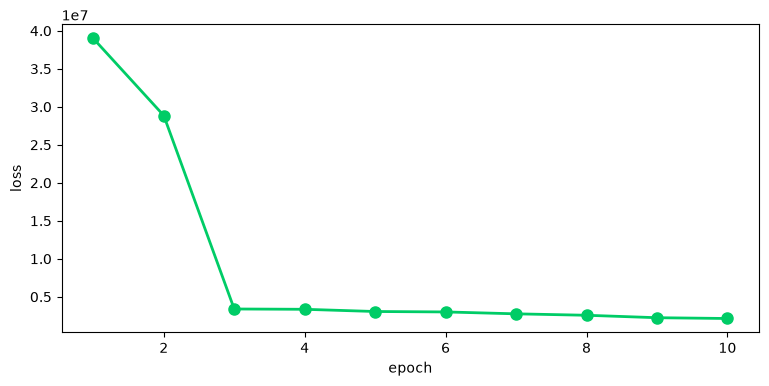

In [42]:
plt.figure(figsize=(9,4))
plt.plot(range(1,len(loss_logger.losses)+1),loss_logger.losses,marker ='o',
         color ='#00cc66',linewidth = 2,markersize = 8
         )
plt.xlabel("epoch")
plt.ylabel("loss")


In [43]:
word = 'good'
# word = 'delicious'
if word in model.wv:
    vec = model.wv[word]
    print(f"Vector for word '{word}': shape ={vec.shape}")
    print(f":10 values {vec[:10].round(4)}")
else:
    print(f"'{word}' not in data - try another word")

Vector for word 'good': shape =(300,)
:10 values [-0.1142  0.0741 -0.187  -0.1117 -0.1456 -0.1798  0.0565 -0.1164  0.0502
  0.0094]


In [44]:
def similarwords(word,topn = 10):
    """Print Top-N similar words to the searched word"""
    if word not in model.wv:
        print(f"'{word}' not in vocab")
        return
    similar = model.wv.most_similar(word,topn = topn )
    print(f"most similar words to '{word}':")
    print(f" {'Word':<20}{'similar words ':>10}")
    print(" "+"-"*32)
    for w,score in similar:
        print(f"   {w:<20}{score:>10.4f}")


In [45]:
similarwords('delicious')
similarwords('terrible')
similarwords('good')

most similar words to 'delicious':
 Word                similar words 
 --------------------------------
   tasty                   0.7924
   yummy                   0.7636
   flavorful               0.6791
   wonderful               0.6675
   dellicious              0.6416
   yummilicious            0.6391
   fantastic               0.6277
   deeeeeelicious          0.6164
   awesome                 0.6151
   amazazing               0.6138
most similar words to 'terrible':
 Word                similar words 
 --------------------------------
   horrible                0.6131
   awful                   0.5854
   disgusting              0.5701
   bad                     0.5450
   worst                   0.5241
   yuck                    0.5169
   nasty                   0.5002
   disguisting             0.4871
   poor                    0.4826
   ewwwwwwwwww             0.4597
most similar words to 'good':
 Word                similar words 
 --------------------------------
   great   

In [46]:
# check the list that "good" and "delicious" are near to each other as they should be

In [47]:
def analogy (positive,negative,topn = 5):
    """SOvle : positive[0] is to positive[1] as negative[0] is to ?
    """

    try:
        results = model.wv.most_similar(
            positive=positive,
            negative = negative,
            topn = topn
        )
        q = "+".join(positive)+"-"+"-".join(negative)
        print(f"\n{q}")
        for w,score in results:
            print(f"{w:<20} (similarity:{score:.4f})")
    except KeyError as e:
        print(f"word not in vocab{e}")

In [48]:
analogy(['sweet ','coffee'],negative=['bitter'])
analogy(['cheap ','excellent'],negative=['bad'])
analogy(['buy ','hated'],negative=['loved'])


word not in vocab"Key 'sweet ' not present in vocabulary"
word not in vocab"Key 'cheap ' not present in vocabulary"
word not in vocab"Key 'buy ' not present in vocabulary"


In [51]:

word_pair = [('delicious','good'),
             ('awful','terrible'),
             ('coffee','tea'),
             ('pizza','soda'),
             ('delicious','awful'),
             ('chocolate','shipping')
]
print(f"{'Pair':<30}{'Similarity':>10}")
print("-"*42)
for w1,w2 in word_pair:
    if w1 in model.wv and w2 in model.wv:
        sim = model.wv.similarity(w1,w2)
        bar = "-"* int(sim*20)
        print(f"({w1:<12},{w2:<12}) {sim:>6.4f}{bar}")
    else:
        missing = w1 if w1 not in model.wv else w2
        print(f"({w1:<12},{w2:<12})")

Pair                          Similarity
------------------------------------------
(delicious   ,good        ) 0.6073------------
(awful       ,terrible    ) 0.5854-----------
(coffee      ,tea         ) 0.5274----------
(pizza       ,soda        ) 0.2137----
(delicious   ,awful       ) 0.2639-----
(chocolate   ,shipping    ) 0.2292----


In [52]:
def doesnt_match(words):
    vocab_words = [w for w in words if w in model.wv]
    missing = set(words) - set(vocab_words)
    if missing:
        print(f"Skipping {missing}")
    if len(vocab_words)<2:
        print("not enough word in vocba")
        return
    odd = model.wv.doesnt_match(vocab_words)
    print(f"From{vocab_words}: odd one out {odd}")
    

In [53]:
doesnt_match(['breakfast','lunch','dinner','shipping'])

From['breakfast', 'lunch', 'dinner', 'shipping']: odd one out shipping


In [57]:
doesnt_match(['coffee', 'tea', 'juice', 'keyboard'])

From['coffee', 'tea', 'juice', 'keyboard']: odd one out keyboard


In [59]:
word_group  = {
    'Positive taste':['delicious','tasty',
        'yummy'    ,
        'flavorful'      ,
        'wonderful'      ,
        'dellicious'     ,
        'yummilicious'   ,
        'fantastic'      ,
        'deeeeeelicious' ,
        'awesome'        ,
        'amazazing'      ],
   'Negative quality':['terrible', 'awful', 'horrible', 'disgusting', 'bland', 'stale'],
   'Beverages'       :['coffee', 'tea', 'juice', 'water', 'soda', 'wine'],
   'Snacks'          :['chips','cookie','cracker','pretzel','popcorn','nut'],
   'Shipping/service':['shipping','delivery','package','arrival','damaged','refund'],
   'Price/Values'    :['cheap','expensive','pricey','affordable','overpriced','worth']
}

In [74]:
words_to_plot= []
labels_to_plot=[]
group_names=[]


In [75]:
for group_name, word_list in word_group.items():
    for word in word_list:
        if word in model.wv:       # only add words the model actually learned
            words_to_plot.append(word)
            labels_to_plot.append(group_name)

# Get the 300-dim vectors for all selected words
vectors = np.array([model.wv[w] for w in words_to_plot])

print(f"✅ Collected {len(words_to_plot)} words across {len(word_group)} groups")
print(f"   Vector matrix shape: {vectors.shape}")

✅ Collected 40 words across 6 groups
   Vector matrix shape: (40, 300)


In [76]:
pca = PCA(n_components=min(50, len(words_to_plot) - 1), random_state=42)
vectors_50d = pca.fit_transform(vectors)

In [77]:
print(f"PCA:{vectors.shape[1]}D ->{vectors_50d.shape[1]}D")
print(f"Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

PCA:300D ->39D
Explained variance: 100.0%


In [80]:
tsne = TSNE(n_components=2,
            perplexity=min(15,len(words_to_plot)//2),
            max_iter= 1000,
            random_state= 42,
            learning_rate='auto',
            init='pca'
            )

In [83]:
vectors_2d = tsne.fit_transform(vectors_50d)
print(f"tsne completed:{vectors_50d.shape[1]}D to 2D")

tsne completed:39D to 2D


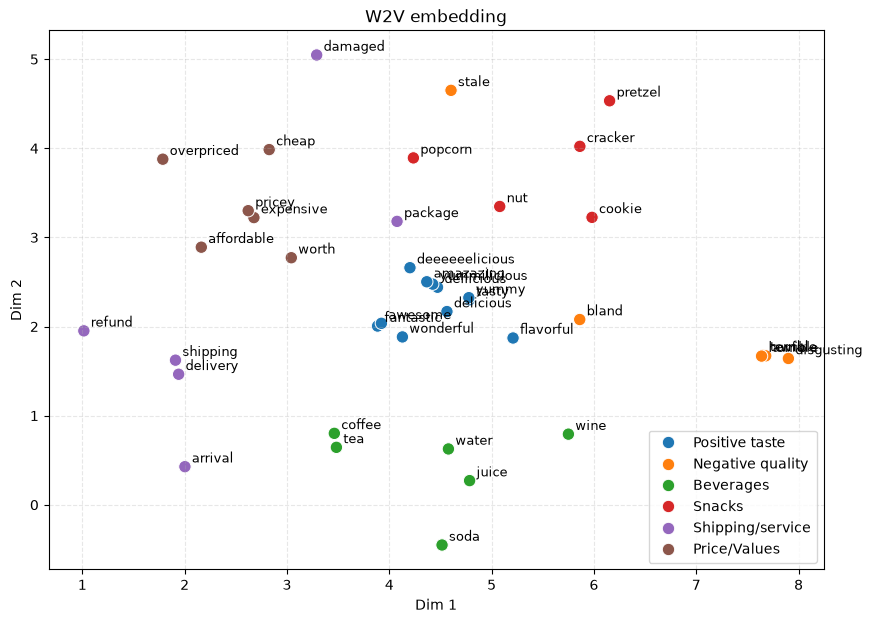

In [90]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    x = vectors_2d[:,0],
    y = vectors_2d[:,1],
    hue= labels_to_plot,
    s = 80,
    ax = ax
)
for i,word in enumerate(words_to_plot):
    ax.annotate(
        word,vectors_2d[i],xytext= (5,3),textcoords = "offset points",fontsize = 9

    )
ax.set(
    title = "W2V embedding",
    xlabel = "Dim 1",
    ylabel = "Dim 2"
)
ax.grid(True,linestyle = "--",alpha = 0.3)
plt.show()

In [91]:
heatmap_words = ['delicious','tasty','awful','terrible','coffee','tea','shipping',
                 'delivery','fresh','stale']

In [92]:
heatmap_words = [w for w in heatmap_words if w in model.wv]



In [94]:
n = len(heatmap_words)
sim_matrix = np.zeros((n,n))

for i,w1 in enumerate (heatmap_words):
    for j,w2 in enumerate(heatmap_words):
        sim_matrix[i,j] = model.wv.similarity(w1,w2) # Cosine Similarity

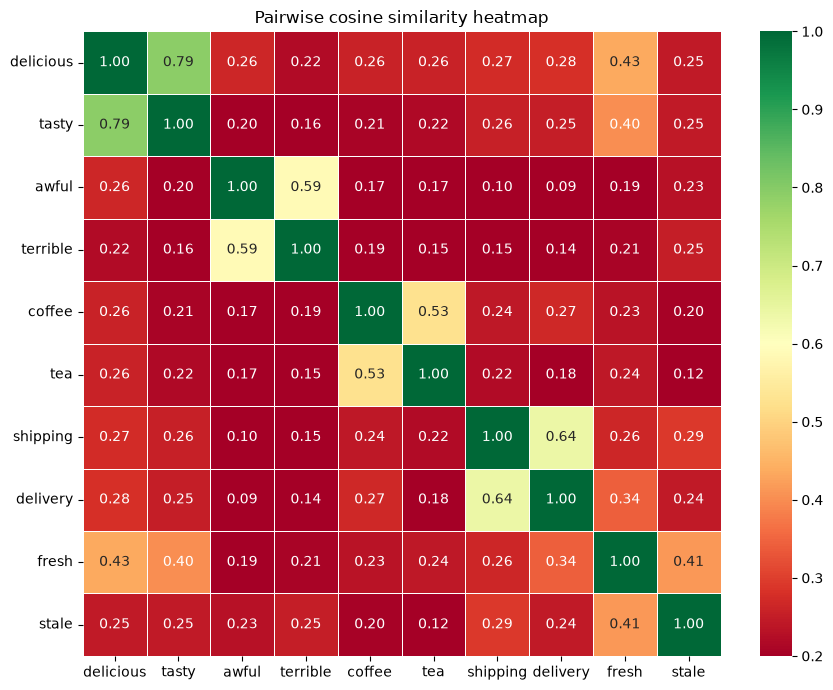

In [103]:
fig,ax = plt.subplots(figsize=(9,7))
sns.heatmap(
    sim_matrix,
    xticklabels=heatmap_words,
    yticklabels=heatmap_words,
    annot=True,
    fmt= '.2f',
    cmap = 'RdYlGn',
    vmin=0.2,vmax = 1.0,
    linewidth = 0.5,
    ax = ax
)
ax.set_title("Pairwise cosine similarity heatmap")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

In [105]:
vocab = model.wv
print(f"Total vocab:{len(vocab):,} words and vector size {vocab.vector_size} dimensions")

Total vocab:37,985 words and vector size 300 dimensions


In [106]:
top_words = [
    (word,vocab.get_vecattr(word,'count'))
    for word in list(vocab.key_to_index.keys())[:30]
]

In [107]:
top_words_sorted = sorted(top_words,key=lambda x:x[1],reverse = True)[:20]

In [118]:
print(f"most freq words in vocab : {'Word':<20}{'Count':>10}")
print("                           "+"-"*32)
for word,count in top_words_sorted:
    print(f"                           {word:<20}  {count:>10,}")

most freq words in vocab : Word                     Count
                           --------------------------------
                           like                     282,546
                           good                     254,405
                           taste                    242,692
                           great                    240,308
                           product                  205,128
                           flavor                   202,707
                           coffee                   201,803
                           love                     199,947
                           one                      199,415
                           tea                      176,568
                           food                     167,244
                           dog                      128,846
                           would                    125,840
                           get                      122,831
                           make           

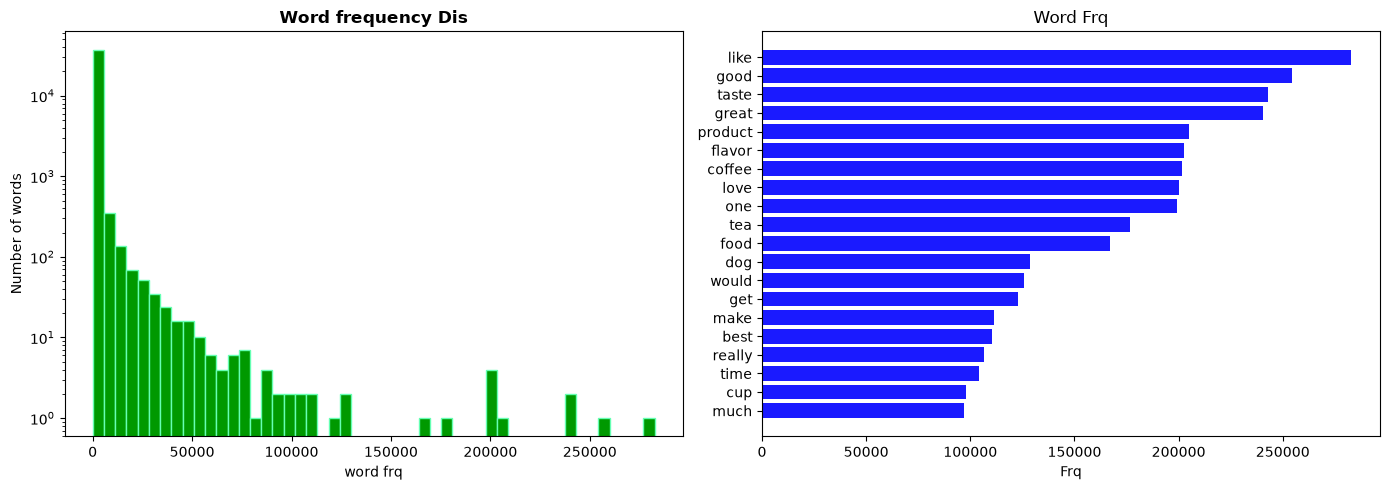

In [128]:
all_counts = [
    vocab.get_vecattr(word,'count')
    for word in vocab.key_to_index
]
fig,axes = plt.subplots(1,2,figsize = (14,5))

axes[0].hist(all_counts,bins = 50,color = '#009900',edgecolor = '#66ffb3')
axes[0].set_yscale('log')
axes[0].set_title("Word frequency Dis", fontweight = 'bold')
axes[0].set_xlabel("word frq")
axes[0].set_ylabel("Number of words")

words_only = [w for w, _ in top_words_sorted[:25]]
count_only = [c for _, c in top_words_sorted[:25]]
axes[1].barh(words_only[::-1],count_only[::-1],color = '#1a1aff')
axes[1].set_title("Word Frq")
axes[1].set_xlabel("Frq")

plt.tight_layout()
plt.show()

15 words most similar to 'chocolate':

(1, 2).cocoa               0.6610**************************
(2, 2).donchels            0.6322*************************
(3, 2).fudge               0.6268*************************
(4, 2).chocolatey          0.6209************************
(5, 2).girardelli          0.6141************************
(6, 2).choc                0.6123************************
(7, 2).nibby               0.6115************************
(8, 2).ghirardelli         0.6069************************
(9, 2).chocloate           0.6057************************
(10, 2).truffes             0.6045************************
(11, 2).chocolicious        0.6028************************
(12, 2).dark                0.6012************************
(13, 2).fudgie              0.5986***********************
(14, 2).hershy              0.5984***********************
(15, 2).vipsusie            0.5979***********************


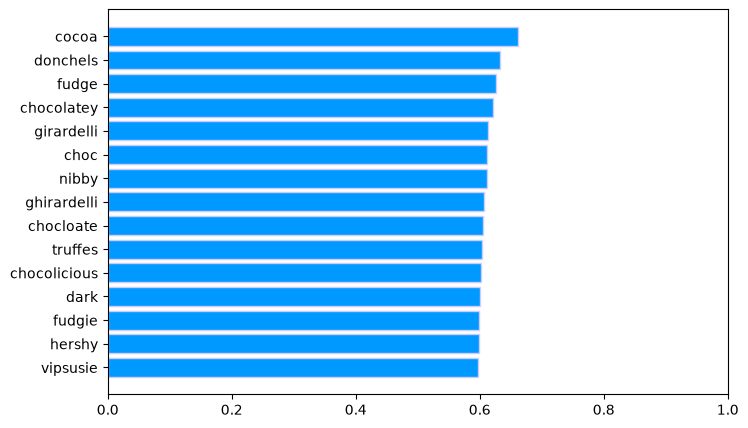

In [138]:
query_words = 'chocolate'
top_n = 15

if query_words  in model.wv:
    results = model.wv.most_similar(query_words,topn= top_n)
    print(f"{top_n} words most similar to '{query_words}':\n")
    for i, (word,score) in enumerate(results,1):
        bar = '*'* int(score*40)
        print(f"{i,2}.{word:<20}{score:.4f}{bar}")
    
    words_r = [w for w, _ in results]
    scores_r = [s for _,s in results]
    plt.figure(figsize=(8,5))
    bars = plt.barh(words_r[::-1],scores_r[::-1],color= '#0099ff',edgecolor = '#ccccff')
    plt.xlim(0,1)
else:
    print(f"{query_words} is not in the vocabulary.")
    print(" Try a dif word")